# Transformer desde cero con PyTorch — cuaderno basado en la mini‑course de 10 días

Este cuaderno convierte en formato **Jupyter Notebook** la página:

**“Building Transformer Models from Scratch with PyTorch (10-day Mini-Course)”**  
Machine Learning Mastery — Adrian Tam  
https://machinelearningmastery.com/building-transformer-models-from-scratch-with-pytorch-10-day-mini-course/

## Qué incluye este notebook

Sigue la misma idea de las 10 lecciones del artículo:

1. Obtener datos de texto  
2. Entrenar un tokenizador BPE  
3. Positional encoding con **RoPE**  
4. **Grouped Query Attention (GQA)**  
5. **Causal mask**  
6. **SwiGLU** y **Mixture of Experts (MoE)**  
7. **RMSNorm** y skip connections  
8. Montar el transformer completo  
9. Entrenarlo para **next-token prediction**  
10. Generar texto

## Nota importante

He mantenido la estructura del artículo, pero el cuaderno está **adaptado para ser más ejecutable y didáctico**:

- usa una **configuración pequeña** por defecto, para que sea más realista en un portátil,
- incluye **fallback** a un mini corpus local si falla la descarga de Project Gutenberg,
- corrige algunos detalles de implementación para que las formas de los tensores sean consistentes.

> Si quieres acercarte más al artículo original, más abajo tienes también una configuración “ARTICLE_CONFIG”.

## Requisitos

En una celda de Jupyter, instala lo necesario si hace falta:

```python
!pip install -q torch tokenizers requests tqdm
```

Este notebook usa `torch.nn.functional.scaled_dot_product_attention(..., enable_gqa=True)`, por lo que conviene una versión moderna de PyTorch.

In [1]:
import os
import math
import json
import requests
import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

## Lección 1 — Obtener los datos

El artículo propone descargar varios libros de **Project Gutenberg** como corpus inicial.  
Aquí hacemos lo mismo, pero con manejo de errores y un corpus de respaldo para que el cuaderno siga funcionando incluso sin internet.

In [2]:
DATASOURCE = {
    "memoirs_of_grant": "https://www.gutenberg.org/ebooks/4367.txt.utf-8",
    "frankenstein": "https://www.gutenberg.org/ebooks/84.txt.utf-8",
    "sleepy_hollow": "https://www.gutenberg.org/ebooks/41.txt.utf-8",
    "origin_of_species": "https://www.gutenberg.org/ebooks/2009.txt.utf-8",
    "makers_of_many_things": "https://www.gutenberg.org/ebooks/28569.txt.utf-8",
    "common_sense": "https://www.gutenberg.org/ebooks/147.txt.utf-8",
    "economic_peace": "https://www.gutenberg.org/ebooks/15776.txt.utf-8",
    "the_great_war_3": "https://www.gutenberg.org/ebooks/29265.txt.utf-8",
    "elements_of_style": "https://www.gutenberg.org/ebooks/37134.txt.utf-8",
    "problem_of_philosophy": "https://www.gutenberg.org/ebooks/5827.txt.utf-8",
    "nights_in_london": "https://www.gutenberg.org/ebooks/23605.txt.utf-8",
}

DATA_DIR = "gutenberg_data"
os.makedirs(DATA_DIR, exist_ok=True)

FALLBACK_TEXTS = [
    "Once upon a time there was a small model learning to predict the next token in a sentence.",
    "Transformers process sequences in parallel and use attention to connect tokens with context.",
    "Project Gutenberg contains many public-domain books that can be used for small educational experiments.",
    "The goal of this notebook is not to train a production model but to understand every block of the architecture."
]

def download_books(datasource=DATASOURCE, data_dir=DATA_DIR, timeout=20):
    downloaded = []
    for filename, url in datasource.items():
        out_path = os.path.join(data_dir, f"{filename}.txt")
        if os.path.exists(out_path):
            downloaded.append(out_path)
            continue
        try:
            response = requests.get(url, timeout=timeout)
            response.raise_for_status()
            with open(out_path, "wb") as f:
                f.write(response.content)
            downloaded.append(out_path)
            print(f"Descargado: {filename}")
        except Exception as e:
            print(f"No se pudo descargar {filename}: {e}")
    return downloaded

downloaded_files = download_books()
print(f"Archivos disponibles: {len(downloaded_files)}")

Archivos disponibles: 11


In [3]:
def preprocess_gutenberg(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    start = text.find("*** START OF THE PROJECT GUTENBERG EBOOK")
    if start != -1:
        start = text.find("\n", start) + 1
    else:
        start = 0

    end = text.find("*** END OF THE PROJECT GUTENBERG EBOOK")
    if end == -1:
        end = len(text)

    text = text[start:end].strip()
    text = "\n".join(line.strip() for line in text.split("\n") if line.strip())
    return text

def get_dataset_text():
    files = [os.path.join(DATA_DIR, f"{name}.txt") for name in DATASOURCE if os.path.exists(os.path.join(DATA_DIR, f"{name}.txt"))]
    if files:
        return [preprocess_gutenberg(path) for path in files]
    return FALLBACK_TEXTS

texts = get_dataset_text()
print(f"Número de documentos: {len(texts)}")
print(texts[0][:500])

Número de documentos: 11
PERSONAL MEMOIRS OF U. S. GRANT, complete
by U. S. Grant
PREFACE.
"Man proposes and God disposes."  There are but few important events in
the affairs of men brought about by their own choice.
Although frequently urged by friends to write my memoirs I had
determined never to do so, nor to write anything for publication.  At
the age of nearly sixty-two I received an injury from a fall, which
confined me closely to the house while it did not apparently affect my
general health. This made study a pl


## Lección 2 — Entrenar un tokenizador BPE

La página entrena un tokenizador **BPE** con la librería `tokenizers`, usando `ByteLevel` y una **vocabulario de 10 000** tokens.  
Aquí hacemos lo mismo, aunque puedes bajar el tamaño si quieres ir más rápido.

In [4]:
VOCAB_SIZE = 10_000

tokenizer = Tokenizer(models.BPE(unk_token="[unk]"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tokenizer.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=["[pad]", "[eos]", "[unk]"],
    show_progress=True,
)

tokenizer.train_from_iterator(texts, trainer=trainer)
tokenizer.enable_padding(
    pad_id=tokenizer.token_to_id("[pad]"),
    pad_token="[pad]"
)
tokenizer.save("gutenberg_tokenizer.json")

print("Tokenizer guardado en gutenberg_tokenizer.json")
print("Tamaño real del vocabulario:", tokenizer.get_vocab_size())




Tokenizer guardado en gutenberg_tokenizer.json
Tamaño real del vocabulario: 10000


In [5]:
# Recarga opcional
tokenizer = Tokenizer.from_file("gutenberg_tokenizer.json")

sample_text = "Transformers are powerful sequence models."
encoded = tokenizer.encode(sample_text)
decoded = tokenizer.decode(encoded.ids)

print("Texto original: ", sample_text)
print("IDs:            ", encoded.ids[:30])
print("Reconstrucción: ", decoded)

Texto original:  Transformers are powerful sequence models.
IDs:             [7365, 1255, 253, 278, 5929, 235, 279, 400, 863, 2944, 14]
Reconstrucción:   Transformers are powerful sequence models.


## Lección 3 — Positional Encoding con RoPE

El artículo usa **Rotary Positional Encoding (RoPE)**.  
RoPE no suma un embedding posicional clásico, sino que rota pares de componentes del embedding usando senos y cosenos.

A continuación implementamos una versión compatible con tensores de forma:

- `q`: `(batch, heads, seq_len, head_dim)`
- `k`: `(batch, heads, seq_len, head_dim)`

In [6]:
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary_pos_emb(x, cos, sin):
    return (x * cos) + (rotate_half(x) * sin)

class RotaryPositionalEncoding(nn.Module):
    def __init__(self, dim, max_seq_len=1024, base=10000):
        super().__init__()
        if dim % 2 != 0:
            raise ValueError("head_dim debe ser par para usar RoPE.")
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        position = torch.arange(max_seq_len).float()
        sinusoid_inp = torch.outer(position, inv_freq)  # (seq_len, dim/2)

        cos = torch.cat([sinusoid_inp.cos(), sinusoid_inp.cos()], dim=-1)
        sin = torch.cat([sinusoid_inp.sin(), sinusoid_inp.sin()], dim=-1)

        # Forma preparada para broadcast sobre (B, H, N, D)
        self.register_buffer("cos", cos.unsqueeze(0).unsqueeze(0), persistent=False)  # (1,1,N,D)
        self.register_buffer("sin", sin.unsqueeze(0).unsqueeze(0), persistent=False)  # (1,1,N,D)

    def forward(self, x):
        seq_len = x.size(-2)
        cos = self.cos[:, :, :seq_len, :]
        sin = self.sin[:, :, :seq_len, :]
        return apply_rotary_pos_emb(x, cos, sin)

# Prueba rápida
sequence = torch.randn(2, 4, 10, 32)  # (batch, heads, seq, head_dim)
rope = RotaryPositionalEncoding(dim=32, max_seq_len=128)
new_sequence = rope(sequence)

print("Forma original:", sequence.shape)
print("Forma tras RoPE:", new_sequence.shape)

Forma original: torch.Size([2, 4, 10, 32])
Forma tras RoPE: torch.Size([2, 4, 10, 32])


## Lecciones 4 y 5 — GQA + Causal Mask

La página introduce:

- **Grouped Query Attention (GQA)**, donde hay más cabezas de consulta que de clave/valor,
- y una **causal mask** para que el token `i` no vea tokens futuros `j > i`.

Primero definimos la máscara causal y luego una capa de GQA.

In [7]:
def create_causal_mask(seq_len, device=None, dtype=torch.float32):
    # forma base: (seq_len, seq_len)
    mask = torch.full((seq_len, seq_len), float("-inf"), device=device, dtype=dtype)
    mask = torch.triu(mask, diagonal=1)
    # broadcastable a (batch, heads, seq_len, seq_len)
    return mask.unsqueeze(0).unsqueeze(0)

class GQA(nn.Module):
    def __init__(self, hidden_dim, num_heads, num_kv_heads, dropout=0.1):
        super().__init__()
        if hidden_dim % num_heads != 0:
            raise ValueError("hidden_dim debe ser divisible por num_heads")
        if num_heads % num_kv_heads != 0:
            raise ValueError("num_heads debe ser divisible por num_kv_heads para GQA")

        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads
        self.head_dim = hidden_dim // num_heads
        self.dropout = dropout

        self.q_proj = nn.Linear(hidden_dim, num_heads * self.head_dim)
        self.k_proj = nn.Linear(hidden_dim, num_kv_heads * self.head_dim)
        self.v_proj = nn.Linear(hidden_dim, num_kv_heads * self.head_dim)
        self.out_proj = nn.Linear(num_heads * self.head_dim, hidden_dim)

    def forward(self, q, k, v, mask=None, rope=None):
        bq, nq, hidden_dim = q.shape
        bk, nk, _ = k.shape
        bv, nv, _ = v.shape

        q = self.q_proj(q).view(bq, nq, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(k).view(bk, nk, self.num_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(v).view(bv, nv, self.num_kv_heads, self.head_dim).transpose(1, 2)

        if rope is not None:
            q = rope(q)
            k = rope(k)

        attn_dropout = self.dropout if self.training else 0.0

        out = F.scaled_dot_product_attention(
            q.contiguous(),
            k.contiguous(),
            v.contiguous(),
            attn_mask=mask,
            dropout_p=attn_dropout,
            enable_gqa=True,
        )

        out = out.transpose(1, 2).reshape(bq, nq, hidden_dim).contiguous()
        out = self.out_proj(out)
        return out

# Prueba rápida
x = torch.randn(2, 16, 64)  # (batch, seq_len, hidden_dim)
mask = create_causal_mask(seq_len=16, device=x.device)
rope = RotaryPositionalEncoding(dim=16, max_seq_len=128)  # hidden_dim/num_heads = 64/4 = 16

gqa = GQA(hidden_dim=64, num_heads=4, num_kv_heads=2, dropout=0.1)
y = gqa(x, x, x, mask=mask, rope=rope)

print("Entrada:", x.shape)
print("Salida: ", y.shape)

Entrada: torch.Size([2, 16, 64])
Salida:  torch.Size([2, 16, 64])


## Lecciones 6 y 7 — SwiGLU, MoE, RMSNorm y Decoder Layer

La mini‑course usa:

- **SwiGLU** como MLP de cada experto,
- un **MoE** con enrutador `top-k`,
- **RMSNorm** y conexiones residuales en un bloque decoder-only.

In [8]:
class SwiGLU(nn.Module):
    def __init__(self, hidden_dim, intermediate_dim):
        super().__init__()
        self.gate = nn.Linear(hidden_dim, intermediate_dim)
        self.up = nn.Linear(hidden_dim, intermediate_dim)
        self.down = nn.Linear(intermediate_dim, hidden_dim)
        self.act = nn.SiLU()

    def forward(self, x):
        x = self.act(self.gate(x)) * self.up(x)
        x = self.down(x)
        return x

class MoELayer(nn.Module):
    def __init__(self, hidden_dim, intermediate_dim, num_experts, top_k=2):
        super().__init__()
        if top_k > num_experts:
            raise ValueError("top_k no puede ser mayor que num_experts")
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList(
            [SwiGLU(hidden_dim, intermediate_dim) for _ in range(num_experts)]
        )
        self.router = nn.Linear(hidden_dim, num_experts)

    def forward(self, hidden_states):
        batch_size, seq_len, hidden_dim = hidden_states.shape
        hidden_states_reshaped = hidden_states.reshape(-1, hidden_dim)  # (tokens, hidden_dim)

        router_logits = self.router(hidden_states_reshaped)             # (tokens, num_experts)
        top_k_logits, top_k_indices = torch.topk(router_logits, self.top_k, dim=-1)
        top_k_probs = F.softmax(top_k_logits, dim=-1)

        output = torch.zeros_like(hidden_states_reshaped)

        # Recorremos experto por experto
        unique_experts = torch.unique(top_k_indices)
        for expert_tensor in unique_experts:
            expert_id = int(expert_tensor.item())

            # posiciones donde ese experto ha sido elegido
            token_pos, rank_pos = (top_k_indices == expert_id).nonzero(as_tuple=True)
            if token_pos.numel() == 0:
                continue

            expert_input = hidden_states_reshaped[token_pos]
            expert_output = self.experts[expert_id](expert_input)
            expert_weight = top_k_probs[token_pos, rank_pos].unsqueeze(-1)

            output[token_pos] += expert_output * expert_weight

        return output.view(batch_size, seq_len, hidden_dim)

class DecoderLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads, num_kv_heads, moe_experts, moe_topk, dropout=0.1):
        super().__init__()
        self.self_attn = GQA(hidden_dim, num_heads, num_kv_heads, dropout)
        self.mlp = MoELayer(hidden_dim, 4 * hidden_dim, moe_experts, moe_topk)
        self.norm1 = nn.RMSNorm(hidden_dim)
        self.norm2 = nn.RMSNorm(hidden_dim)

    def forward(self, x, mask=None, rope=None):
        out = self.norm1(x)
        out = self.self_attn(out, out, out, mask=mask, rope=rope)
        x = x + out

        out = self.norm2(x)
        out = self.mlp(out)
        x = x + out
        return x

# Prueba rápida
decoder = DecoderLayer(hidden_dim=64, num_heads=4, num_kv_heads=2, moe_experts=4, moe_topk=2)
out = decoder(x, mask=mask, rope=rope)
print(out.shape)

torch.Size([2, 16, 64])


## Lección 8 — El modelo completo

El artículo propone una configuración grande:

```python
{
    "num_layers": 8,
    "num_heads": 8,
    "num_kv_heads": 4,
    "hidden_dim": 768,
    "moe_experts": 8,
    "moe_topk": 3,
    "max_seq_len": 512,
    "vocab_size": len(tokenizer.get_vocab()),
    "dropout": 0.1,
}
```

Aquí la conservamos como referencia, pero por defecto usaremos una versión más ligera.

In [9]:
ARTICLE_CONFIG = {
    "num_layers": 8,
    "num_heads": 8,
    "num_kv_heads": 4,
    "hidden_dim": 768,
    "moe_experts": 8,
    "moe_topk": 3,
    "max_seq_len": 512,
    "vocab_size": tokenizer.get_vocab_size(),
    "dropout": 0.1,
}

DEMO_CONFIG = {
    "num_layers": 2,
    "num_heads": 4,
    "num_kv_heads": 2,
    "hidden_dim": 128,
    "moe_experts": 4,
    "moe_topk": 2,
    "max_seq_len": 64,
    "vocab_size": tokenizer.get_vocab_size(),
    "dropout": 0.1,
}

model_config = DEMO_CONFIG
model_config

{'num_layers': 2,
 'num_heads': 4,
 'num_kv_heads': 2,
 'hidden_dim': 128,
 'moe_experts': 4,
 'moe_topk': 2,
 'max_seq_len': 64,
 'vocab_size': 10000,
 'dropout': 0.1}

In [10]:
class TextGenerationModel(nn.Module):
    def __init__(
        self,
        num_layers,
        num_heads,
        num_kv_heads,
        hidden_dim,
        moe_experts,
        moe_topk,
        max_seq_len,
        vocab_size,
        dropout=0.1,
    ):
        super().__init__()
        head_dim = hidden_dim // num_heads
        self.max_seq_len = max_seq_len
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rope = RotaryPositionalEncoding(dim=head_dim, max_seq_len=max_seq_len)
        self.decoders = nn.ModuleList([
            DecoderLayer(hidden_dim, num_heads, num_kv_heads, moe_experts, moe_topk, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.RMSNorm(hidden_dim)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, ids, mask=None):
        x = self.embedding(ids)
        for decoder in self.decoders:
            x = decoder(x, mask=mask, rope=self.rope)
        x = self.norm(x)
        return self.out(x)

model = TextGenerationModel(**model_config)

dummy_ids = torch.randint(0, model_config["vocab_size"], (2, model_config["max_seq_len"]))
dummy_mask = create_causal_mask(model_config["max_seq_len"], device=dummy_ids.device)
dummy_out = model(dummy_ids, mask=dummy_mask)

print("Input IDs:", dummy_ids.shape)
print("Logits:   ", dummy_out.shape)

Input IDs: torch.Size([2, 64])
Logits:    torch.Size([2, 64, 10000])


## Lección 9 — Dataset y entrenamiento

La página usa un dataset autoregresivo: a partir de una secuencia de longitud `L`, la entrada es:

- `x = [t0, t1, ..., t(L-1)]`

y el objetivo es:

- `y = [t1, t2, ..., tL]`

Es decir, el modelo aprende a **predecir el siguiente token**.

In [14]:
class GutenbergDataset(torch.utils.data.Dataset):
    def __init__(self, text, tokenizer, seq_len=64):
        self.seq_len = seq_len
        self.encoded = tokenizer.encode(text).ids

    def __len__(self):
        return max(0, len(self.encoded) - self.seq_len - 1)

    def __getitem__(self, idx):
        chunk = self.encoded[idx:idx + self.seq_len + 1]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y

full_text = "\n\n".join(texts)
dataset = GutenbergDataset(full_text, tokenizer, seq_len=model_config["max_seq_len"])

BATCH_SIZE = 64
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Tamaño del dataset:", len(dataset))
xb, yb = next(iter(dataloader))
print("x batch:", xb.shape)
print("y batch:", yb.shape)

Tamaño del dataset: 1438633
x batch: torch.Size([64, 64])
y batch: torch.Size([64, 64])


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TextGenerationModel(**model_config).to(device)

N_EPOCHS = 5
LR = 5e-4
CLIP_NORM = 1.0
MAX_TRAIN_STEPS = 50  # Para demo. Sube este valor si quieres entrenar más.

optimizer = optim.AdamW(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id("[pad]"))

total_steps = min(MAX_TRAIN_STEPS, max(1, len(dataloader) * N_EPOCHS))
warmup_steps = max(1, min(10, total_steps // 5))

warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps,
)

cosine_steps = max(1, total_steps - warmup_steps)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cosine_steps,
    eta_min=0.0,
)

scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps],
)

print("device:", device)
print("total_steps:", total_steps)
print("warmup_steps:", warmup_steps)

device: cpu
total_steps: 50
warmup_steps: 10


In [16]:
history = []
best_loss = float("inf")

global_step = 0
for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm.tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    for x_batch, y_batch in progress_bar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        mask = create_causal_mask(x_batch.shape[1], device=device)

        optimizer.zero_grad()
        logits = model(x_batch, mask=mask)

        loss = loss_fn(logits.view(-1, logits.shape[-1]), y_batch.view(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()

        if global_step < total_steps:
            scheduler.step()

        epoch_loss += loss.item()
        history.append(loss.item())
        global_step += 1

        progress_bar.set_postfix(loss=float(loss.item()))

        #if global_step >= MAX_TRAIN_STEPS:
        #    break

    avg_loss = epoch_loss / max(1, min(len(dataloader), MAX_TRAIN_STEPS))
    print(f"Epoch {epoch+1}: avg_loss = {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "textgen_model_demo.pth")

    if global_step >= MAX_TRAIN_STEPS:
        break

print("Entrenamiento terminado.")
print("Mejor pérdida media:", best_loss)

Epoch 1/5:   2%|██▍                                                                                                                                        | 398/22479 [03:21<3:06:38,  1.97it/s, loss=7.79]


KeyboardInterrupt: 

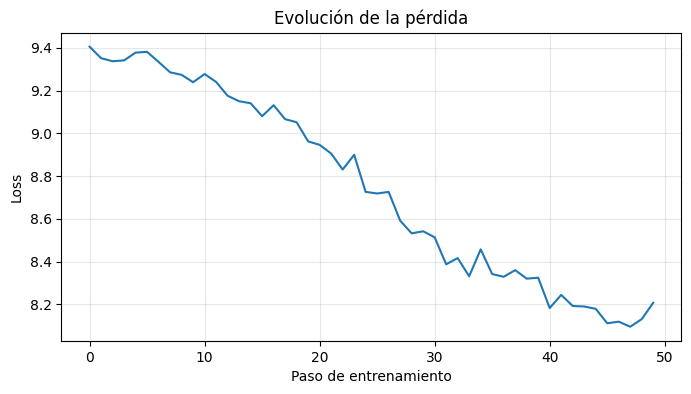

In [14]:
# Visualización simple de la pérdida
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Paso de entrenamiento")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida")
plt.grid(True, alpha=0.3)
plt.show()

## Lección 10 — Generación de texto

La página genera texto:

- poniendo el modelo en `eval()`,
- desactivando gradientes con `torch.no_grad()`,
- muestreando el siguiente token desde la distribución softmax,
- y deteniéndose si aparece `[eos]`.

Aquí añadimos además un control para que el contexto no supere `max_seq_len`.

In [15]:
def generate_text(model, tokenizer, prompt, max_new_tokens=80, temperature=1.0):
    model.eval()
    device = next(model.parameters()).device

    input_ids = tokenizer.encode(prompt).ids
    input_ids = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)

    eos_id = tokenizer.token_to_id("[eos]")

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # limitamos el contexto al tamaño máximo del modelo
            input_context = input_ids[:, -model.max_seq_len:]
            mask = create_causal_mask(input_context.shape[1], device=device)

            logits = model(input_context, mask=mask)
            next_token_logits = logits[:, -1, :] / max(temperature, 1e-6)

            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            input_ids = torch.cat([input_ids, next_token], dim=1)

            if eos_id is not None and next_token.item() == eos_id:
                break

    return tokenizer.decode(input_ids[0].tolist())

test_prompts = [
    "Once upon a time",
    "Transformers are",
    "In the beginning",
]

for prompt in test_prompts:
    generated = generate_text(model, tokenizer, prompt, max_new_tokens=60, temperature=0.9)
    print("=" * 80)
    print("PROMPT:", prompt)
    print("GENERADO:")
    print(generated)
    print()

PROMPT: Once upon a time
GENERADO:
 Once upon a timeremain piano intuitive sc representatives scattered interests converted Continentvisionissfind Soenny grace evidence shade preparedharicatedctionsestererve hisugues require held than sterilityperfect station phys L deboccupprepared lamellæ artilleryIST within forth Burkesville tertiaryant motor writers diountwenty State piecesvil Orleansises veget prefer Brigadierdown girls

PROMPT: Transformers are
GENERADO:
 Transformers areorse ke probability correct Hundred mistake unusoticYou supply threaten explanation assembledITH townincre treated mesterhaus Ne * wooden Pemberton deliveredorsesirst droveanci assuredly surprisingot Moreover greateralways belong enemyamaugVILLEensemanyomeonies breatrieEnglishcloselying edge Po rel lightedoot 20 pushenemy heard.... 24structure looked

PROMPT: In the beginning
GENERADO:
 In the beginning withinsem enjoy retreat dawwhel accepted false logical lessertwoalysousand economic teams spaceaure reader f ri

## Ideas para seguir ampliándolo

1. Cambiar `DEMO_CONFIG` por `ARTICLE_CONFIG`.  
2. Usar un corpus más grande.  
3. Entrenar más pasos o más épocas.  
4. Añadir validación y cálculo de perplexity.  
5. Sustituir `MoELayer` por una MLP estándar para comparar velocidad y calidad.  
6. Cambiar GQA por multi-head attention clásica y comparar.

## Ejercicios propuestos

- ¿Por qué una vocabulario de 10 000 tokens suele quedarse corto para un modelo serio?
- ¿Qué ventaja aporta RoPE frente a embeddings posicionales aprendidos?
- ¿Qué cambia exactamente entre multi-head attention y GQA?
- ¿Por qué en modelos decoder-only es imprescindible la causal mask?
- ¿Qué ganamos y qué complicamos al usar MoE?